In [ ]:
# --- Holt vs Holt-Winters Example for Seasonal Sales/Passengers Forecasting ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing



In [ ]:
# -----------------------------------------------------------
# 1. Load data
# -----------------------------------------------------------
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rakannimer/air-passengers")
# https://www.kaggle.com/datasets/rakannimer/air-passengers

print("Path to dataset files:", path)




100%|██████████| 764/764 [00:00<00:00, 1.26MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rakannimer/air-passengers/versions/1


In [ ]:
file_path = path + "/AirPassengers.csv"
data = pd.read_csv(file_path
data = data.rename(columns={"#Passengers": "Passengers"})
display(data.head())




,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


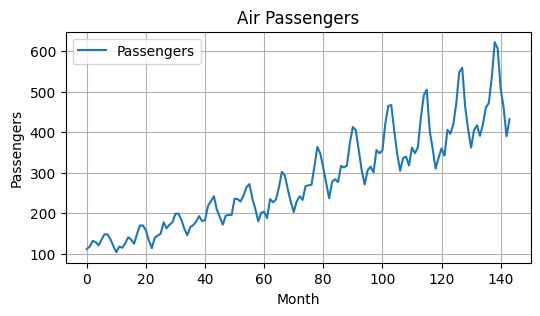

In [ ]:
# -----------------------------------------------------------
# Plot synthetic data
# -----------------------------------------------------------
plt.figure(figsize=(6, 3))
plt.plot(data.index, data["Passengers"], label="Passengers")
plt.title("Air Passengers")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# -----------------------------------------------------------
# 2. Split into train and test
# -----------------------------------------------------------
train = data.iloc[:-12]
test = data.iloc[-12:]




In [ ]:
# -----------------------------------------------------------
# 3. Holt’s Linear Trend Model (no seasonality)
# -----------------------------------------------------------
holt_model = ExponentialSmoothing(train["Passengers"],
                                  trend="add",
                                  seasonal=None).fit(optimized=True)
holt_forecast = holt_model.forecast(24)



In [ ]:
# -----------------------------------------------------------
# 4. Holt-Winters Seasonal Model (additive seasonality)
# -----------------------------------------------------------
hw_model = ExponentialSmoothing(train["Passengers"],
                                trend="add",
                                seasonal="add",
                                seasonal_periods=12).fit(optimized=True)
hw_forecast = hw_model.forecast(24)

In [ ]:
# -----------------------------------------------------------
# 5. Combine forecasts
# -----------------------------------------------------------
results = pd.DataFrame({
    "Actual": test["Passengers"],
    "Holt": holt_forecast,
    "Holt_Winters": hw_forecast
})
print("\nForecast Comparison:")
print(results.round(2))




Forecast Comparison:
     Actual    Holt  Holt_Winters
132   417.0  407.24        415.45
133   391.0  409.47        397.09
134   419.0  411.71        457.47
135   461.0  413.95        445.37
136   472.0  416.18        466.18
137   535.0  418.42        520.73
138   622.0  420.66        592.42
139   606.0  422.89        598.84
140   508.0  425.13        498.83
141   461.0  427.37        442.38
142   390.0  429.60        396.51
143   432.0  431.84        424.29
144     NaN  434.08        446.14
145     NaN  436.31        427.77
146     NaN  438.55        488.16
147     NaN  440.79        476.05
148     NaN  443.02        496.87
149     NaN  445.26        551.42
150     NaN  447.50        623.11
151     NaN  449.73        629.53
152     NaN  451.97        529.51
153     NaN  454.21        473.07
154     NaN  456.44        427.20
155     NaN  458.68        454.97


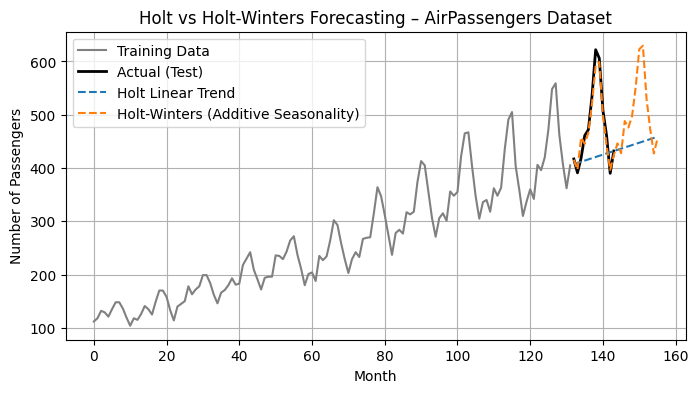

In [ ]:
# -----------------------------------------------------------
# 6. Plot comparison
# -----------------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(train.index, train["Passengers"], label="Training Data", color="gray")
plt.plot(test.index, test["Passengers"], label="Actual (Test)", color="black", linewidth=2)
plt.plot(holt_forecast.index, holt_forecast, "--", label="Holt Linear Trend")
plt.plot(hw_forecast.index, hw_forecast, "--", label="Holt-Winters (Additive Seasonality)")
plt.title("Holt vs Holt-Winters Forecasting – AirPassengers Dataset")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# -----------------------------------------------------------
# 7. Evaluate forecast accuracy
# -----------------------------------------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_holt = mean_absolute_error(test["Passengers"], holt_forecast)
rmse_holt = np.sqrt(mean_squared_error(test["Passengers"], holt_forecast))

mae_hw = mean_absolute_error(test["Passengers"], hw_forecast)
rmse_hw = np.sqrt(mean_squared_error(test["Passengers"], hw_forecast))

print("Holt's Linear Trend Model:")
print(f"  MAE: {mae_holt:.2f}")
print(f"  RMSE: {rmse_holt:.2f}")
print("\nHolt-Winters Seasonal Model:")
print(f"  MAE: {mae_hw:.2f}")
print(f"  RMSE: {rmse_hw:.2f}")

Holt's Linear Trend Model:
  MAE: 66.31
  RMSE: 92.67

Holt-Winters Seasonal Model:
  MAE: 13.38
  RMSE: 16.98
